# Cervical Cancer Risk — Model Development and Evaluation

This notebook builds a reproducible classifier for the `Biopsy` outcome using
pre-diagnostic risk factors. It deliberately excludes other screening and diagnosis
results to reduce target leakage.

The workflow emphasizes honest evaluation on imbalanced data and interpretability.
It is an educational demonstration—not a clinically validated diagnostic tool.

## 1. Imports, reproducibility, and paths

A fixed random seed makes the split and model repeatable. Pipelines are used so
preprocessing is learned from training data only, preventing information from the
test set from leaking into imputation or scaling.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data" / "cervical_cancer.csv").exists():
    PROJECT_DIR = PROJECT_DIR / "001_Cervical_Cancer_Predection_with_ML"

DATA_PATH = PROJECT_DIR / "data" / "cervical_cancer.csv"
ASSET_DIR = PROJECT_DIR / "docs" / "assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load and clean the data

The source uses `?` for missing data. We convert every column to numeric after
replacing that marker. This mirrors the EDA notebook and creates a single,
predictable representation for scikit-learn.

In [2]:
data = (
    pd.read_csv(DATA_PATH)
    .replace("?", np.nan)
    .apply(pd.to_numeric, errors="coerce")
)

TARGET = "Biopsy"
LEAKAGE_COLUMNS = [
    "Hinselmann", "Schiller", "Citology",
    "Dx:Cancer", "Dx:CIN", "Dx:HPV", "Dx",
]

X = data.drop(columns=[TARGET, *LEAKAGE_COLUMNS])
y = data[TARGET].astype(int)

assert not y.isna().any(), "Target labels cannot be missing."
assert set(y.unique()) == {0, 1}, "This workflow expects a binary target."

print(f"Features retained: {X.shape[1]}")
print(f"Positive class: {y.sum()} of {len(y)} ({y.mean():.2%})")

Features retained: 28
Positive class: 55 of 858 (6.41%)


## 3. Create a stratified holdout set

The holdout set is used only once for final comparison. `stratify=y` preserves the
rare positive-class proportion in both partitions. Without stratification, a small
test set could contain too few positive cases for a meaningful evaluation.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "rows": [len(y_train), len(y_test)],
        "positive_cases": [int(y_train.sum()), int(y_test.sum())],
        "positive_rate": [y_train.mean(), y_test.mean()],
    },
    index=["Training", "Test"],
)
split_summary

,rows,positive_cases,positive_rate
Training,686,44,0.064140
Test,172,11,0.063953


## 4. Define leakage-safe preprocessing

Median imputation is robust to skewed numerical features. Logistic regression also
needs scaling because its optimization and coefficients are sensitive to feature
units. The random forest does not require scaling, so it receives imputed values
only. Crucially, each transformer is fitted inside its pipeline during training.

In [4]:
numeric_features = X.columns.tolist()

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        )
    ],
    remainder="drop",
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), numeric_features),
    ],
    remainder="drop",
)

## 5. Define two complementary models

Logistic regression is the transparent baseline: it is fast, stable, and easy to
interpret. Random forest captures nonlinear relationships and feature interactions.
Both use balanced class weights so errors on the rare positive class receive more
attention than they would under ordinary accuracy optimization.

In [5]:
models = {
    "Logistic regression": Pipeline(
        steps=[
            ("preprocess", linear_preprocessor),
            (
                "model",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=2_000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random forest": Pipeline(
        steps=[
            ("preprocess", tree_preprocessor),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=500,
                    min_samples_leaf=3,
                    class_weight="balanced_subsample",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

## 6. Cross-validation on training data

Five-fold stratified cross-validation measures how stable each model is across
different training subsets without touching the holdout set. PR-AUC is especially
informative for rare positive outcomes; ROC-AUC measures ranking across thresholds;
recall measures how many positive cases are found.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
}

cv_rows = []
for name, pipeline in models.items():
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"model": name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).set_index("model")
cv_results.round(3)

,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std
model,,,,,,,,,,
Logistic regression,0.573,0.074,0.133,0.030,0.431,0.103,0.111,0.023,0.176,0.035
Random forest,0.622,0.045,0.161,0.058,0.044,0.089,0.067,0.133,0.053,0.107


## 7. Fit models and evaluate the untouched test set

The default probability threshold is 0.5. We report several metrics because each
answers a different question. In a screening context, recall often matters greatly,
but false positives also have real consequences; threshold selection must therefore
be made with clinical and operational stakeholders, not from this notebook alone.

In [7]:
test_rows = []
predictions = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    probability = pipeline.predict_proba(X_test)[:, 1]
    prediction = (probability >= 0.5).astype(int)
    predictions[name] = {"probability": probability, "prediction": prediction}
    test_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, prediction),
            "precision": precision_score(y_test, prediction, zero_division=0),
            "recall": recall_score(y_test, prediction, zero_division=0),
            "f1": f1_score(y_test, prediction, zero_division=0),
            "roc_auc": roc_auc_score(y_test, probability),
            "pr_auc": average_precision_score(y_test, probability),
        }
    )

test_results = pd.DataFrame(test_rows).set_index("model")
test_results.round(3)

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Logistic regression,0.738,0.095,0.364,0.151,0.578,0.092
Random forest,0.924,0.250,0.091,0.133,0.685,0.185


## 8. Confusion matrices

A confusion matrix exposes the actual error counts hidden by summary metrics.
False negatives are positive biopsies the model misses; false positives are people
flagged by the model whose biopsy is negative.

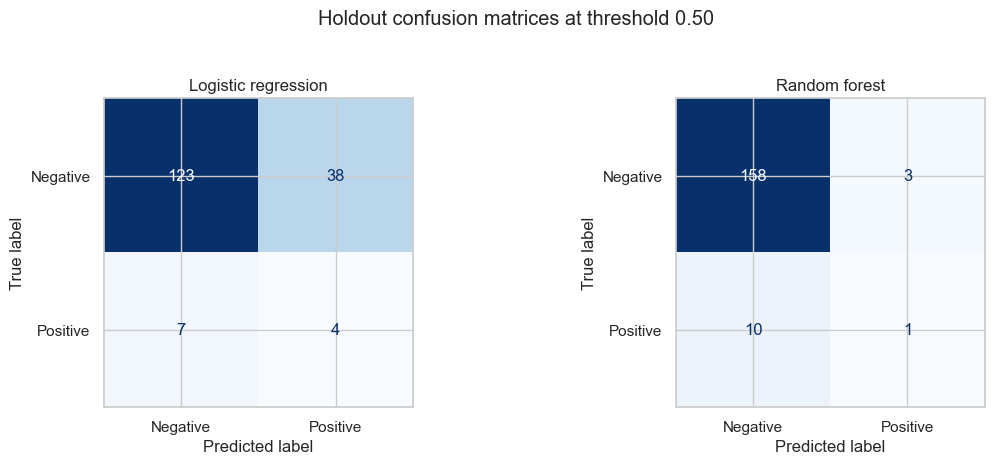

In [8]:
fig, axes = plt.subplots(1, len(models), figsize=(12, 4.5))
for ax, (name, values) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        values["prediction"],
        display_labels=["Negative", "Positive"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(name)
fig.suptitle("Holdout confusion matrices at threshold 0.50", y=1.03)
fig.tight_layout()
fig.savefig(ASSET_DIR / "confusion_matrices.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. ROC and precision–recall curves

Curves show model behavior across every threshold instead of locking evaluation to
0.5. The precision–recall curve is particularly useful here because the positive
class is rare and it directly displays the trade-off between finding positives and
limiting false alarms.

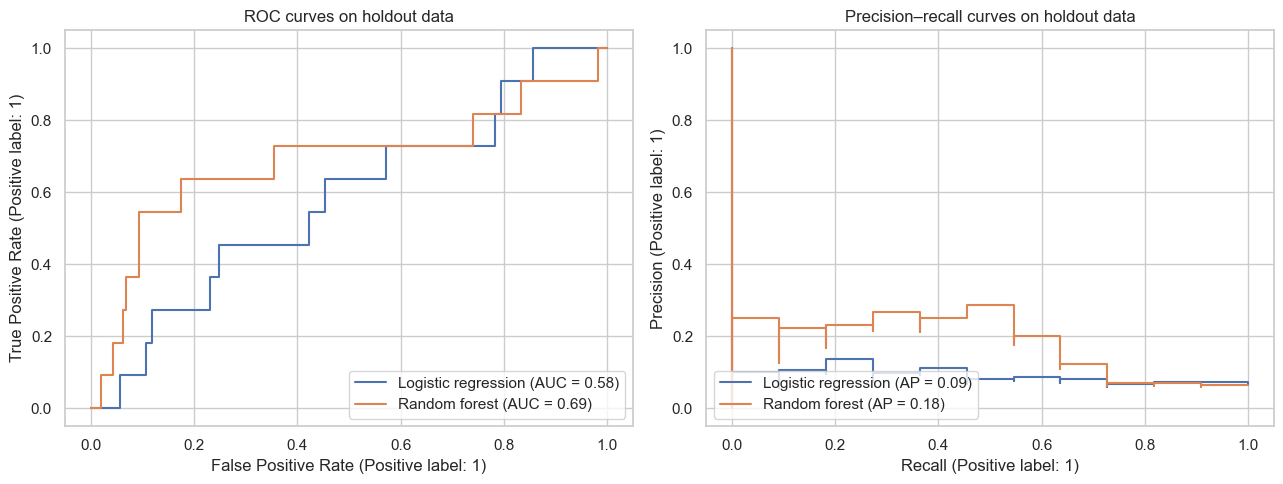

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, values in predictions.items():
    RocCurveDisplay.from_predictions(y_test, values["probability"], name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, values["probability"], name=name, ax=axes[1])
axes[0].set_title("ROC curves on holdout data")
axes[1].set_title("Precision–recall curves on holdout data")
fig.tight_layout()
fig.savefig(ASSET_DIR / "evaluation_curves.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. Detailed classification reports

Per-class results prevent the majority negative class from dominating the story.
Support is the number of true examples in each class and should always be read
alongside precision and recall.

In [10]:
for name, values in predictions.items():
    print(f"\n{name}\n{'-' * len(name)}")
    print(classification_report(y_test, values["prediction"], target_names=["Negative", "Positive"], zero_division=0))


Logistic regression
-------------------
              precision    recall  f1-score   support

    Negative       0.95      0.76      0.85       161
    Positive       0.10      0.36      0.15        11

    accuracy                           0.74       172
   macro avg       0.52      0.56      0.50       172
weighted avg       0.89      0.74      0.80       172


Random forest
-------------
              precision    recall  f1-score   support

    Negative       0.94      0.98      0.96       161
    Positive       0.25      0.09      0.13        11

    accuracy                           0.92       172
   macro avg       0.60      0.54      0.55       172
weighted avg       0.90      0.92      0.91       172



## 11. Model interpretation with permutation importance

Permutation importance measures how much ROC-AUC falls when one feature is shuffled
in the holdout data. It works consistently across both model types and reflects
predictive reliance rather than claiming causality. With a small positive class,
the ranking is exploratory and should be validated on external data.

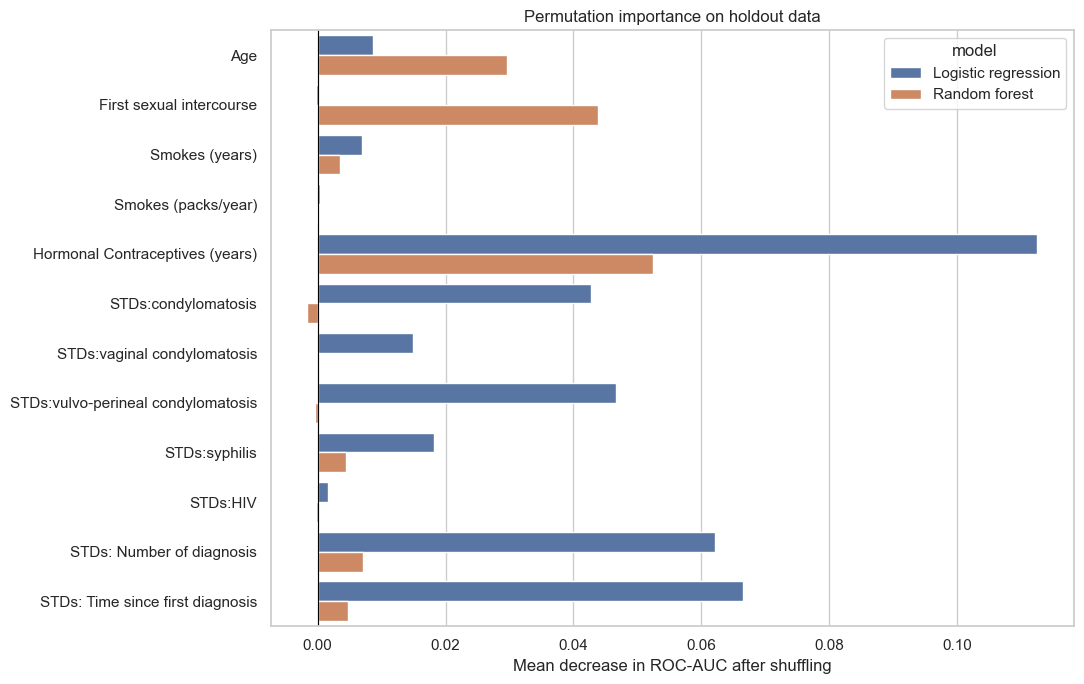

In [11]:
importance_rows = []
for name, pipeline in models.items():
    result = permutation_importance(
        pipeline,
        X_test,
        y_test,
        scoring="roc_auc",
        n_repeats=20,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    for feature, mean, std in zip(X.columns, result.importances_mean, result.importances_std):
        importance_rows.append({"model": name, "feature": feature, "importance": mean, "std": std})

importance = pd.DataFrame(importance_rows)
top_features = (
    importance.groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .head(12)
    .index
)
plot_data = importance[importance["feature"].isin(top_features)].copy()

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=plot_data, x="importance", y="feature", hue="model", errorbar=None, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Permutation importance on holdout data", xlabel="Mean decrease in ROC-AUC after shuffling", ylabel="")
fig.tight_layout()
fig.savefig(ASSET_DIR / "permutation_importance.png", dpi=160, bbox_inches="tight")
plt.show()

## 12. Interpretation, limitations, and next steps

- The dataset is small and the positive biopsy class is rare, so estimates have
  substantial uncertainty.
- Missing values are imputed; missingness itself may contain patterns that deserve
  further investigation.
- The analysis avoids obvious diagnostic leakage, but temporal ordering should be
  confirmed with domain experts.
- Performance from one hospital and one holdout split does not establish external
  validity, fairness, calibration, or clinical usefulness.
- A production study would require external cohorts, calibration analysis,
  subgroup evaluation, threshold selection, privacy review, and clinical oversight.

The appropriate “best model” depends on the cost of missed cases versus false
alerts. The metrics above support that decision; they do not make it automatically.

In [12]:
comparison = test_results.sort_values(["recall", "pr_auc"], ascending=False)
print("Models ranked by recall, then PR-AUC:")
display(comparison.round(3))

Models ranked by recall, then PR-AUC:


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Logistic regression,0.738,0.095,0.364,0.151,0.578,0.092
Random forest,0.924,0.250,0.091,0.133,0.685,0.185
